# EDA 11.2: Review Volume and Revenue Analysis

This notebook analyzes whether review volume reflects sales volume, whether higher review count is associated with higher Revenue, whether rating changes are followed by Revenue changes, and which leakage-safe historical review features may help forecasting or explainability.

## 1. Setup and File Discovery

Locate required and optional CSV files under the current working directory. Missing files are reported and the notebook continues where possible.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 240)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

ROOT = Path.cwd()
FILES = ['reviews.csv', 'sales.csv', 'products.csv', 'orders.csv', 'order_items.csv', 'returns.csv']
REQUIRED = {'reviews.csv', 'sales.csv'}

def normalize_name(name):
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def discover_csvs(root):
    found = {}
    for path in root.rglob('*.csv'):
        key = path.name.lower()
        if key not in found:
            found[key] = path
    return found

csv_files = discover_csvs(ROOT)
selected_paths = {name: csv_files.get(name.lower()) for name in FILES}
file_status = pd.DataFrame([
    {'file': name, 'required': name in REQUIRED, 'found': path is not None, 'path': str(path) if path else None}
    for name, path in selected_paths.items()
])
display(file_status)

for name, path in selected_paths.items():
    if path is None and name in REQUIRED:
        warnings.warn(f'Required file missing: {name}. The notebook will continue where possible.')

,file,required,found,path
0,reviews.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...
1,sales.csv,True,True,D:\Code\Datathon 2026\datathon-2026-round-1\sa...
2,products.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\pr...
3,orders.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
4,order_items.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\or...
5,returns.csv,False,True,D:\Code\Datathon 2026\datathon-2026-round-1\re...


## 2. Load Reviews, Sales, and Optional Files

Load all available inputs safely with pandas and display basic schema information.

In [2]:
def load_csv_safe(path):
    if path is None:
        return None
    try:
        return pd.read_csv(path)
    except Exception as exc:
        warnings.warn(f'Failed to load {path}: {exc}')
        return None

data = {name.replace('.csv', ''): load_csv_safe(path) for name, path in selected_paths.items()}

schema_rows = []
for name, df in data.items():
    schema_rows.append({
        'dataset': name,
        'loaded': df is not None,
        'rows': None if df is None else len(df),
        'columns': None if df is None else ', '.join(map(str, df.columns[:20]))
    })
schema_df = pd.DataFrame(schema_rows)
display(schema_df)

C:\Users\ACER\AppData\Local\Temp\ipykernel_20528\3867194689.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,dataset,loaded,rows,columns
0,reviews,True,113551,"review_id, order_id, product_id, customer_id, ..."
1,sales,True,3833,"Date, Revenue, COGS"
2,products,True,2412,"product_id, product_name, category, segment, s..."
3,orders,True,646945,"order_id, order_date, customer_id, zip, order_..."
4,order_items,True,714669,"order_id, product_id, quantity, unit_price, di..."
5,returns,True,39939,"return_id, order_id, product_id, return_date, ..."


## 3. Identify Review, Rating, Date, Revenue, Product, Order, and Quantity Columns

Use tolerant matching for common naming variants. The notebook continues if some fields cannot be identified.

In [3]:
def normalized_map(columns):
    return {normalize_name(c): c for c in columns}

def find_column(columns, candidates, contains=False):
    nmap = normalized_map(columns)
    normalized_candidates = [normalize_name(c) for c in candidates]
    for cand in normalized_candidates:
        if cand in nmap:
            return nmap[cand]
    if contains:
        for cand in normalized_candidates:
            for ncol, raw in nmap.items():
                if cand in ncol:
                    return raw
    return None

def pick_numeric_revenue(df):
    if df is None:
        return None
    candidates = [
        'revenue', 'sales_amount', 'sales', 'gross_revenue', 'net_revenue',
        'total_revenue', 'amount', 'gmv'
    ]
    col = find_column(df.columns, candidates, contains=True)
    if col is not None:
        return col
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not numeric_cols:
        return None
    ranked = sorted(
        numeric_cols,
        key=lambda c: (
            'revenue' not in normalize_name(c),
            'sale' not in normalize_name(c),
            -float(pd.to_numeric(df[c], errors='coerce').fillna(0).abs().mean())
        )
    )
    return ranked[0] if ranked else None

reviews = data.get('reviews')
sales = data.get('sales')
products = data.get('products')
orders = data.get('orders')
order_items = data.get('order_items')
returns = data.get('returns')

review_cols = {}
if reviews is not None:
    review_cols = {
        'review_id': find_column(reviews.columns, ['review_id', 'id']),
        'product_id': find_column(reviews.columns, ['product_id', 'sku', 'item_id']),
        'order_id': find_column(reviews.columns, ['order_id']),
        'customer_id': find_column(reviews.columns, ['customer_id', 'user_id']),
        'review_date': find_column(reviews.columns, ['review_date', 'date', 'created_at', 'reviewed_at'], contains=True),
        'rating': find_column(reviews.columns, ['rating', 'score', 'stars', 'star_rating'], contains=True),
        'review_text': find_column(reviews.columns, ['review_text', 'review', 'comment', 'review_title'], contains=True),
    }

product_cols = {}
if products is not None:
    product_cols = {
        'product_id': find_column(products.columns, ['product_id', 'sku', 'item_id']),
        'category': find_column(products.columns, ['category', 'product_category']),
        'segment': find_column(products.columns, ['segment', 'product_segment']),
        'product_name': find_column(products.columns, ['product_name', 'name', 'title'], contains=True),
    }

sales_cols = {}
if sales is not None:
    sales_cols = {
        'date': find_column(sales.columns, ['date', 'sales_date', 'order_date', 'transaction_date'], contains=True),
        'revenue': pick_numeric_revenue(sales)
    }

orders_cols = {}
if orders is not None:
    orders_cols = {
        'order_id': find_column(orders.columns, ['order_id']),
        'order_date': find_column(orders.columns, ['order_date', 'date'], contains=True),
    }

order_item_cols = {}
if order_items is not None:
    order_item_cols = {
        'order_id': find_column(order_items.columns, ['order_id']),
        'product_id': find_column(order_items.columns, ['product_id']),
        'quantity': find_column(order_items.columns, ['quantity', 'qty', 'units']),
        'unit_price': find_column(order_items.columns, ['unit_price', 'price', 'selling_price'], contains=True),
        'discount_amount': find_column(order_items.columns, ['discount_amount', 'discount', 'promo_discount'], contains=True),
    }

return_cols = {}
if returns is not None:
    return_cols = {
        'order_id': find_column(returns.columns, ['order_id']),
        'product_id': find_column(returns.columns, ['product_id']),
        'return_date': find_column(returns.columns, ['return_date', 'date'], contains=True),
    }

identified = {
    'reviews': review_cols,
    'products': product_cols,
    'sales': sales_cols,
    'orders': orders_cols,
    'order_items': order_item_cols,
    'returns': return_cols,
}
display(pd.DataFrame(identified).T)

if reviews is not None and (review_cols.get('review_date') is None or review_cols.get('rating') is None):
    warnings.warn('Review date or rating column could not be identified reliably. Some review analysis may be skipped.')
if sales is not None and (sales_cols.get('date') is None or sales_cols.get('revenue') is None):
    warnings.warn('Sales date or Revenue column could not be identified reliably. Some revenue analysis may be skipped.')

,review_id,product_id,order_id,customer_id,review_date,rating,review_text,category,segment,product_name,date,revenue,order_date,quantity,unit_price,discount_amount,return_date
reviews,review_id,product_id,order_id,customer_id,review_date,rating,review_title,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
products,NaN,product_id,NaN,NaN,NaN,NaN,NaN,category,segment,product_name,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Date,Revenue,NaN,NaN,NaN,NaN,NaN
orders,NaN,NaN,order_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,order_date,NaN,NaN,NaN,NaN
order_items,NaN,product_id,order_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,quantity,unit_price,discount_amount,NaN
returns,NaN,product_id,order_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,return_date


## 4. Reviews Data Quality Checks

Standardize review dates and ratings, then inspect missingness, duplicates, and invalid values.

In [4]:
review_warnings = []
reviews_clean = None

if reviews is not None:
    reviews_clean = reviews.copy()
    if review_cols.get('review_date'):
        reviews_clean['review_date_std'] = pd.to_datetime(reviews_clean[review_cols['review_date']], errors='coerce')
    else:
        reviews_clean['review_date_std'] = pd.NaT

    if review_cols.get('rating'):
        reviews_clean['rating_std'] = pd.to_numeric(reviews_clean[review_cols['rating']], errors='coerce')
    else:
        reviews_clean['rating_std'] = np.nan

    for key in ['review_id', 'product_id', 'order_id', 'customer_id']:
        raw = review_cols.get(key)
        reviews_clean[f'{key}_std'] = reviews_clean[raw] if raw else pd.NA

    invalid_rating_mask = reviews_clean['rating_std'].notna() & ~reviews_clean['rating_std'].between(1, 5)
    duplicate_mask = reviews_clean.duplicated(subset=[c for c in ['review_id_std'] if c in reviews_clean.columns and reviews_clean[c].notna().any()])
    if duplicate_mask.sum() == 0:
        duplicate_mask = reviews_clean.duplicated()

    quality = pd.DataFrame([{
        'review_rows': len(reviews_clean),
        'review_date_min': reviews_clean['review_date_std'].min(),
        'review_date_max': reviews_clean['review_date_std'].max(),
        'missing_review_dates': int(reviews_clean['review_date_std'].isna().sum()),
        'missing_ratings': int(reviews_clean['rating_std'].isna().sum()),
        'invalid_ratings': int(invalid_rating_mask.sum()),
        'missing_product_ids': int(reviews_clean['product_id_std'].isna().sum()),
        'missing_order_ids': int(reviews_clean['order_id_std'].isna().sum()),
        'duplicate_reviews': int(duplicate_mask.sum()),
    }])
    display(quality)

    rating_summary = reviews_clean['rating_std'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame('rating_summary')
    display(rating_summary)

    if quality.loc[0, 'missing_review_dates'] > 0:
        review_warnings.append(f"{quality.loc[0, 'missing_review_dates']} reviews have missing review dates")
    if quality.loc[0, 'invalid_ratings'] > 0:
        review_warnings.append(f"{quality.loc[0, 'invalid_ratings']} reviews have invalid ratings outside 1-5")
else:
    warnings.warn('reviews.csv not available.')

,review_rows,review_date_min,review_date_max,missing_review_dates,missing_ratings,invalid_ratings,missing_product_ids,missing_order_ids,duplicate_reviews
0,113551,2012-07-10,2022-12-31,0,0,0,0,0,0


,rating_summary
count,"113,551.0000"
mean,3.9360
std,1.1499
min,1.0000
5%,1.0000
25%,3.0000
50%,4.0000
75%,5.0000
95%,5.0000
max,5.0000


## 5. Prepare Daily and Monthly Review Aggregates

Build daily and monthly review volume, average rating, and low/high rating shares. These support trend analysis and leakage-safe lag features.

In [5]:
LOW_RATING_THRESHOLD = 2
HIGH_RATING_THRESHOLD = 4

daily_reviews = pd.DataFrame()
monthly_reviews = pd.DataFrame()

if reviews_clean is not None and reviews_clean['review_date_std'].notna().any():
    rv = reviews_clean.dropna(subset=['review_date_std']).copy()
    rv['review_day'] = rv['review_date_std'].dt.floor('D')
    rv['review_month'] = rv['review_date_std'].dt.to_period('M').dt.to_timestamp()
    rv['low_rating_flag'] = rv['rating_std'].le(LOW_RATING_THRESHOLD).fillna(False).astype(int)
    rv['high_rating_flag'] = rv['rating_std'].ge(HIGH_RATING_THRESHOLD).fillna(False).astype(int)

    daily_reviews = rv.groupby('review_day').agg(
        review_count=('rating_std', 'size'),
        avg_rating=('rating_std', 'mean'),
        low_rating_count=('low_rating_flag', 'sum'),
        high_rating_count=('high_rating_flag', 'sum'),
    ).reset_index().rename(columns={'review_day': 'date'})
    daily_reviews['low_rating_ratio'] = np.where(daily_reviews['review_count'] > 0, daily_reviews['low_rating_count'] / daily_reviews['review_count'], np.nan)
    daily_reviews['high_rating_ratio'] = np.where(daily_reviews['review_count'] > 0, daily_reviews['high_rating_count'] / daily_reviews['review_count'], np.nan)

    monthly_reviews = rv.groupby('review_month').agg(
        review_count=('rating_std', 'size'),
        avg_rating=('rating_std', 'mean'),
        low_rating_count=('low_rating_flag', 'sum'),
        high_rating_count=('high_rating_flag', 'sum'),
    ).reset_index().rename(columns={'review_month': 'month'})
    monthly_reviews['low_rating_ratio'] = np.where(monthly_reviews['review_count'] > 0, monthly_reviews['low_rating_count'] / monthly_reviews['review_count'], np.nan)
    monthly_reviews['high_rating_ratio'] = np.where(monthly_reviews['review_count'] > 0, monthly_reviews['high_rating_count'] / monthly_reviews['review_count'], np.nan)

    display(daily_reviews.head())
    display(monthly_reviews.head())
else:
    warnings.warn('Cannot build review aggregates because review dates are unavailable.')

,date,review_count,avg_rating,low_rating_count,high_rating_count,low_rating_ratio,high_rating_ratio
0,2012-07-10,1,5.0000,0,1,0.0000,1.0000
1,2012-07-12,1,5.0000,0,1,0.0000,1.0000
2,2012-07-13,2,4.5000,0,2,0.0000,1.0000
3,2012-07-14,2,3.5000,1,1,0.5000,0.5000
4,2012-07-15,4,4.2500,0,4,0.0000,1.0000


,month,review_count,avg_rating,low_rating_count,high_rating_count,low_rating_ratio,high_rating_ratio
0,2012-07-01,220,4.0136,24,171,0.1091,0.7773
1,2012-08-01,1085,3.9558,146,791,0.1346,0.7290
2,2012-09-01,1069,3.9429,133,774,0.1244,0.7240
3,2012-10-01,890,3.9281,122,651,0.1371,0.7315
4,2012-11-01,760,3.9671,107,555,0.1408,0.7303


## 6. Prepare Daily and Monthly Revenue Aggregates

Standardize sales dates and Revenue, then build daily and monthly Revenue time series.

In [6]:
sales_warnings = []
daily_sales = pd.DataFrame()
monthly_sales = pd.DataFrame()
sales_clean = None

if sales is not None and sales_cols.get('date') and sales_cols.get('revenue'):
    sales_clean = sales.copy()
    sales_clean['sales_date_std'] = pd.to_datetime(sales_clean[sales_cols['date']], errors='coerce')
    sales_clean['revenue_std'] = pd.to_numeric(sales_clean[sales_cols['revenue']], errors='coerce')

    sales_quality = pd.DataFrame([{
        'sales_rows': len(sales_clean),
        'sales_date_min': sales_clean['sales_date_std'].min(),
        'sales_date_max': sales_clean['sales_date_std'].max(),
        'missing_sales_dates': int(sales_clean['sales_date_std'].isna().sum()),
        'duplicate_sales_dates': int(sales_clean.duplicated(subset=['sales_date_std']).sum()),
        'zero_revenue_rows': int(sales_clean['revenue_std'].fillna(0).eq(0).sum()),
        'negative_revenue_rows': int(sales_clean['revenue_std'].fillna(0).lt(0).sum()),
    }])
    display(sales_quality)
    display(sales_clean['revenue_std'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).to_frame('revenue_summary'))

    daily_sales = (
        sales_clean.dropna(subset=['sales_date_std'])
        .groupby(sales_clean['sales_date_std'].dt.floor('D'))
        .agg(revenue=('revenue_std', 'sum'))
        .reset_index()
        .rename(columns={'sales_date_std': 'date'})
    )
    monthly_sales = (
        sales_clean.dropna(subset=['sales_date_std'])
        .groupby(sales_clean['sales_date_std'].dt.to_period('M').dt.to_timestamp())
        .agg(revenue=('revenue_std', 'sum'))
        .reset_index()
        .rename(columns={'sales_date_std': 'month'})
    )
else:
    warnings.warn('Cannot build Revenue aggregates because date or Revenue column is unavailable.')

,sales_rows,sales_date_min,sales_date_max,missing_sales_dates,duplicate_sales_dates,zero_revenue_rows,negative_revenue_rows
0,3833,2012-07-04,2022-12-31,0,0,0,0


,revenue_summary
count,"3,833.0000"
mean,"4,286,584.0296"
std,"2,624,840.1982"
min,"279,813.9400"
5%,"1,352,929.2340"
25%,"2,471,088.8200"
50%,"3,647,303.9000"
75%,"5,350,877.2000"
95%,"9,398,759.8720"
max,"20,905,271.3500"


## 7. Review Count Over Time

Inspect daily and monthly review volume and average rating trends over time.

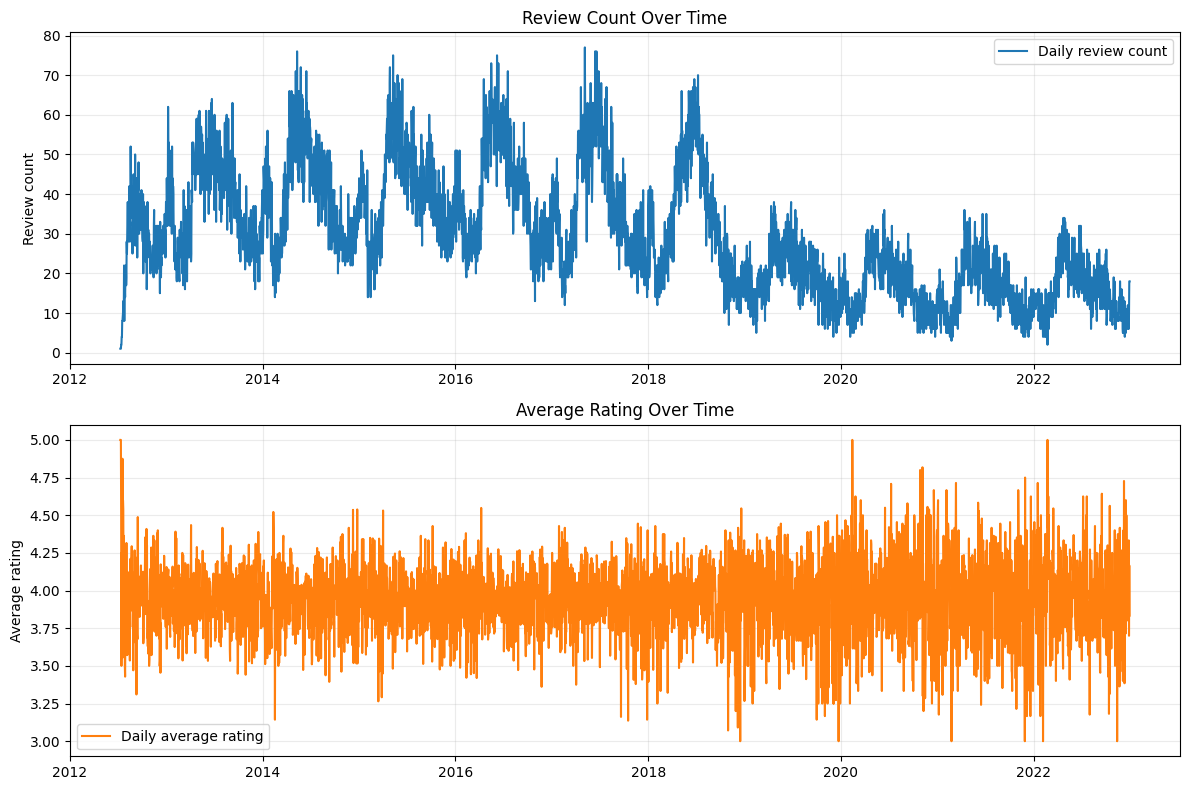

,review_count_first_30d_mean,review_count_last_30d_mean,avg_rating_overall
0,15.7000,9.9333,3.9378


In [7]:
if not daily_reviews.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
    axes[0].plot(daily_reviews['date'], daily_reviews['review_count'], label='Daily review count', color='tab:blue')
    axes[0].set_title('Review Count Over Time')
    axes[0].set_ylabel('Review count')
    axes[0].legend()

    axes[1].plot(daily_reviews['date'], daily_reviews['avg_rating'], label='Daily average rating', color='tab:orange')
    axes[1].set_title('Average Rating Over Time')
    axes[1].set_ylabel('Average rating')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    review_volume_summary = pd.DataFrame([{
        'review_count_first_30d_mean': daily_reviews['review_count'].head(30).mean() if len(daily_reviews) >= 30 else daily_reviews['review_count'].mean(),
        'review_count_last_30d_mean': daily_reviews['review_count'].tail(30).mean() if len(daily_reviews) >= 30 else daily_reviews['review_count'].mean(),
        'avg_rating_overall': daily_reviews['avg_rating'].mean(),
    }])
    display(review_volume_summary)
else:
    print('Daily review aggregates are unavailable.')

## 8. Join Review Metrics with Revenue

Combine review aggregates with Revenue at daily and monthly level. If the daily review series is sparse, monthly comparisons provide a more stable descriptive view.

In [8]:
daily_joined = pd.DataFrame()
monthly_joined = pd.DataFrame()

if not daily_reviews.empty and not daily_sales.empty:
    daily_joined = pd.merge(daily_sales, daily_reviews, on='date', how='outer', indicator=True).sort_values('date')
    daily_joined['review_count'] = daily_joined['review_count'].fillna(0)
    overlap_stats_daily = pd.DataFrame([{
        'daily_review_only_dates': int((daily_joined['_merge'] == 'right_only').sum()),
        'daily_sales_only_dates': int((daily_joined['_merge'] == 'left_only').sum()),
        'daily_overlapping_dates': int((daily_joined['_merge'] == 'both').sum()),
    }])
    display(overlap_stats_daily)
    display(daily_joined.head(10))

if not monthly_reviews.empty and not monthly_sales.empty:
    monthly_joined = pd.merge(monthly_sales, monthly_reviews, on='month', how='outer', indicator=True).sort_values('month')
    monthly_joined['review_count'] = monthly_joined['review_count'].fillna(0)
    overlap_stats_monthly = pd.DataFrame([{
        'monthly_review_only_periods': int((monthly_joined['_merge'] == 'right_only').sum()),
        'monthly_sales_only_periods': int((monthly_joined['_merge'] == 'left_only').sum()),
        'monthly_overlapping_periods': int((monthly_joined['_merge'] == 'both').sum()),
    }])
    display(overlap_stats_monthly)
    display(monthly_joined.head(10))

analysis_freq = 'daily'
if not daily_joined.empty:
    positive_review_share = (daily_joined['review_count'] > 0).mean()
    if positive_review_share < 0.35 and not monthly_joined.empty:
        analysis_freq = 'monthly'
else:
    analysis_freq = 'monthly' if not monthly_joined.empty else 'none'

print(f'Primary descriptive comparison frequency selected: {analysis_freq}')

,daily_review_only_dates,daily_sales_only_dates,daily_overlapping_dates
0,0,8,3825


,date,revenue,review_count,avg_rating,low_rating_count,high_rating_count,low_rating_ratio,high_rating_ratio,_merge
0,2012-07-04,"5,123,547.9400",0.0000,NaN,NaN,NaN,NaN,NaN,left_only
1,2012-07-05,"2,751,773.4500",0.0000,NaN,NaN,NaN,NaN,NaN,left_only
2,2012-07-06,"3,054,029.4200",0.0000,NaN,NaN,NaN,NaN,NaN,left_only
3,2012-07-07,"2,667,930.9400",0.0000,NaN,NaN,NaN,NaN,NaN,left_only
4,2012-07-08,"2,360,851.9000",0.0000,NaN,NaN,NaN,NaN,NaN,left_only
5,2012-07-09,"3,548,386.4600",0.0000,NaN,NaN,NaN,NaN,NaN,left_only
6,2012-07-10,"5,234,938.6200",1.0000,5.0000,0.0000,1.0000,0.0000,1.0000,both
7,2012-07-11,"5,582,884.7800",0.0000,NaN,NaN,NaN,NaN,NaN,left_only
8,2012-07-12,"5,734,632.0200",1.0000,5.0000,0.0000,1.0000,0.0000,1.0000,both
9,2012-07-13,"5,309,511.7100",2.0000,4.5000,0.0000,2.0000,0.0000,1.0000,both


,monthly_review_only_periods,monthly_sales_only_periods,monthly_overlapping_periods
0,0,0,126


,month,revenue,review_count,avg_rating,low_rating_count,high_rating_count,low_rating_ratio,high_rating_ratio,_merge
0,2012-07-01,"130,406,773.5100",220,4.0136,24,171,0.1091,0.7773,both
1,2012-08-01,"159,089,240.3100",1085,3.9558,146,791,0.1346,0.7290,both
2,2012-09-01,"129,307,133.8200",1069,3.9429,133,774,0.1244,0.7240,both
3,2012-10-01,"110,185,694.4500",890,3.9281,122,651,0.1371,0.7315,both
4,2012-11-01,"98,186,295.2400",760,3.9671,107,555,0.1408,0.7303,both
5,2012-12-01,"114,322,610.6900",855,3.9228,118,609,0.1380,0.7123,both
6,2013-01-01,"91,308,677.0300",1250,3.9368,165,906,0.1320,0.7248,both
7,2013-02-01,"109,783,137.9400",697,3.9168,93,498,0.1334,0.7145,both
8,2013-03-01,"151,834,657.2700",866,3.9238,116,607,0.1339,0.7009,both
9,2013-04-01,"198,926,932.0900",1363,3.9413,189,1003,0.1387,0.7359,both


Primary descriptive comparison frequency selected: daily


## 9. Revenue vs Review Count

Measure descriptive association between Revenue and review volume using same-period, lagged, and rolling review metrics.

,metric,correlation
0,revenue_vs_same_period_review_count,0.5598
1,revenue_vs_lagged_review_count_short,0.5379
2,revenue_vs_lagged_review_count_long,0.4331
3,revenue_vs_rolling_historical_review_count,0.5347


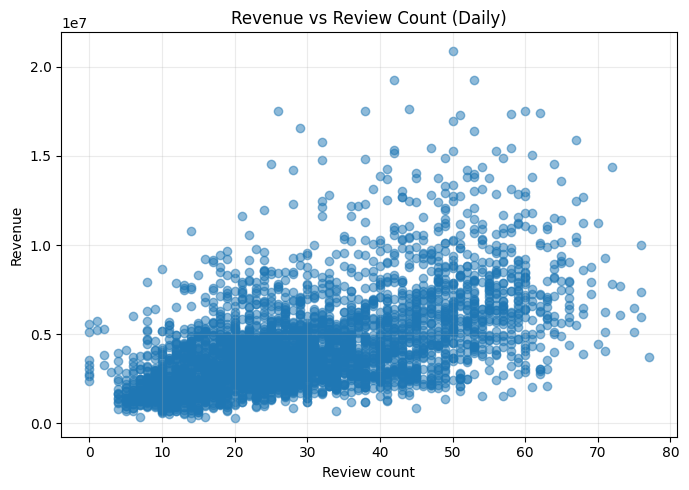

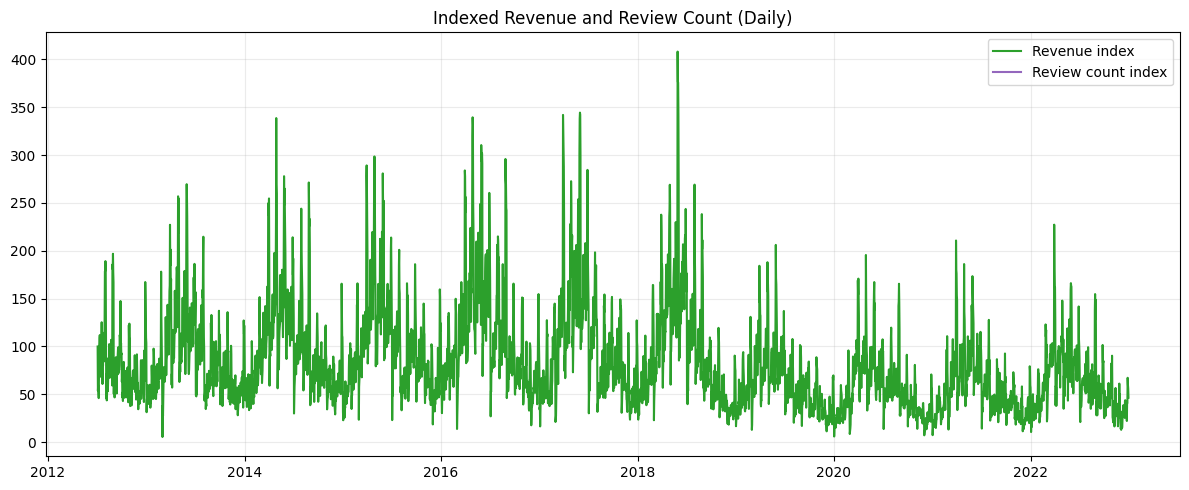

In [9]:
correlation_rows = []

target = daily_joined.copy() if analysis_freq == 'daily' else monthly_joined.copy()
date_col = 'date' if analysis_freq == 'daily' else 'month'

if not target.empty:
    review_lag_short = 7 if analysis_freq == 'daily' else 1
    review_lag_long = 30 if analysis_freq == 'daily' else 3
    roll_window = 30 if analysis_freq == 'daily' else 3
    future_window = 30 if analysis_freq == 'daily' else 1

    target = target.sort_values(date_col).copy()
    target['review_count_lag_short'] = target['review_count'].shift(review_lag_short)
    target['review_count_lag_long'] = target['review_count'].shift(review_lag_long)
    target['review_count_roll_sum'] = target['review_count'].shift(1).rolling(roll_window, min_periods=1).sum()

    correlation_rows.append({'metric': 'revenue_vs_same_period_review_count', 'correlation': target['revenue'].corr(target['review_count'])})
    correlation_rows.append({'metric': 'revenue_vs_lagged_review_count_short', 'correlation': target['revenue'].corr(target['review_count_lag_short'])})
    correlation_rows.append({'metric': 'revenue_vs_lagged_review_count_long', 'correlation': target['revenue'].corr(target['review_count_lag_long'])})
    correlation_rows.append({'metric': 'revenue_vs_rolling_historical_review_count', 'correlation': target['revenue'].corr(target['review_count_roll_sum'])})
    display(pd.DataFrame(correlation_rows))

    fig, ax = plt.subplots(figsize=(7, 5))
    scatter_df = target.dropna(subset=['revenue', 'review_count'])
    ax.scatter(scatter_df['review_count'], scatter_df['revenue'], alpha=0.5, color='tab:blue')
    ax.set_title(f'Revenue vs Review Count ({analysis_freq.title()})')
    ax.set_xlabel('Review count')
    ax.set_ylabel('Revenue')
    plt.tight_layout()
    plt.show()

    if not scatter_df.empty:
        scaled = scatter_df[[date_col, 'revenue', 'review_count']].copy()
        scaled['revenue_index'] = scaled['revenue'] / scaled['revenue'].iloc[0] * 100 if scaled['revenue'].iloc[0] != 0 else np.nan
        scaled['review_index'] = scaled['review_count'] / scaled['review_count'].iloc[0] * 100 if scaled['review_count'].iloc[0] != 0 else np.nan
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(scaled[date_col], scaled['revenue_index'], label='Revenue index', color='tab:green')
        ax.plot(scaled[date_col], scaled['review_index'], label='Review count index', color='tab:purple')
        ax.set_title(f'Indexed Revenue and Review Count ({analysis_freq.title()})')
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print('Joined review and Revenue dataset is unavailable.')

## 10. Review Count as a Sales-Volume Proxy

If orders or order item quantity are available, compare review count with order count, units sold, and Revenue.

,review_vs_order_count,review_vs_quantity_sold,review_vs_item_revenue
0,0.5876,0.5751,0.5611


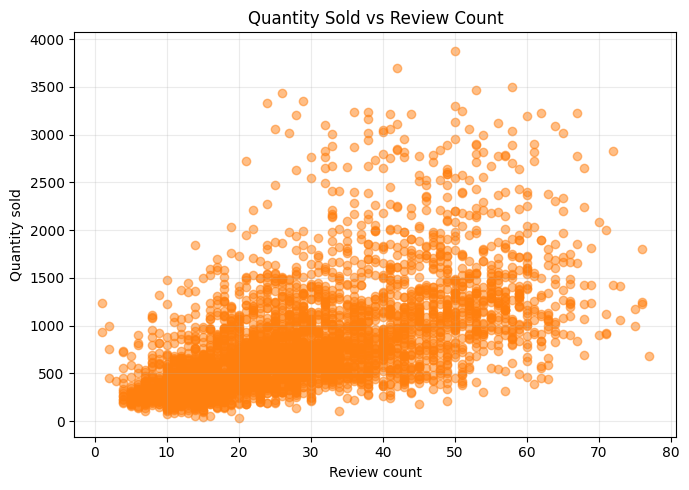

In [10]:
proxy_tables = {}
proxy_notes = []
product_sales = pd.DataFrame()

if orders is not None and orders_cols.get('order_id') and orders_cols.get('order_date'):
    orders_clean = orders.copy()
    orders_clean['order_id_std'] = orders_clean[orders_cols['order_id']]
    orders_clean['order_date_std'] = pd.to_datetime(orders_clean[orders_cols['order_date']], errors='coerce')
else:
    orders_clean = None

if order_items is not None and order_item_cols.get('order_id') and order_item_cols.get('product_id'):
    oi = order_items.copy()
    oi['order_id_std'] = oi[order_item_cols['order_id']]
    oi['product_id_std'] = oi[order_item_cols['product_id']]
    oi['quantity_std'] = pd.to_numeric(oi[order_item_cols['quantity']], errors='coerce') if order_item_cols.get('quantity') else np.nan
    oi['unit_price_std'] = pd.to_numeric(oi[order_item_cols['unit_price']], errors='coerce') if order_item_cols.get('unit_price') else np.nan
    oi['discount_amount_std'] = pd.to_numeric(oi[order_item_cols['discount_amount']], errors='coerce').fillna(0) if order_item_cols.get('discount_amount') else 0
    oi['item_revenue_std'] = oi['quantity_std'] * oi['unit_price_std']
    if orders_clean is not None:
        oi = oi.merge(orders_clean[['order_id_std', 'order_date_std']], on='order_id_std', how='left')
    if products is not None and product_cols.get('product_id'):
        prod_keep = [product_cols['product_id']]
        rename_map = {product_cols['product_id']: 'product_id_std'}
        for label in ['category', 'segment', 'product_name']:
            col = product_cols.get(label)
            if col:
                prod_keep.append(col)
                rename_map[col] = label
        oi = oi.merge(products[prod_keep].rename(columns=rename_map), on='product_id_std', how='left')

    if oi['order_date_std'].notna().any():
        order_daily = oi.groupby(oi['order_date_std'].dt.floor('D')).agg(
            order_count=('order_id_std', 'nunique'),
            quantity_sold=('quantity_std', 'sum'),
            item_revenue=('item_revenue_std', 'sum'),
        ).reset_index().rename(columns={'order_date_std': 'date'})
        review_proxy = pd.merge(daily_reviews, order_daily, on='date', how='inner') if not daily_reviews.empty else pd.DataFrame()
        if not review_proxy.empty:
            proxy_tables['daily_review_proxy'] = review_proxy
            proxy_corr = pd.DataFrame([{
                'review_vs_order_count': review_proxy['review_count'].corr(review_proxy['order_count']),
                'review_vs_quantity_sold': review_proxy['review_count'].corr(review_proxy['quantity_sold']),
                'review_vs_item_revenue': review_proxy['review_count'].corr(review_proxy['item_revenue']),
            }])
            display(proxy_corr)
            fig, ax = plt.subplots(figsize=(7, 5))
            ax.scatter(review_proxy['review_count'], review_proxy['quantity_sold'], alpha=0.5, color='tab:orange')
            ax.set_title('Quantity Sold vs Review Count')
            ax.set_xlabel('Review count')
            ax.set_ylabel('Quantity sold')
            plt.tight_layout()
            plt.show()

    product_sales = oi.groupby('product_id_std').agg(
        product_revenue=('item_revenue_std', 'sum'),
        product_quantity=('quantity_std', 'sum'),
        order_count=('order_id_std', 'nunique'),
        category=('category', 'first') if 'category' in oi.columns else ('product_id_std', 'size'),
        segment=('segment', 'first') if 'segment' in oi.columns else ('product_id_std', 'size'),
        product_name=('product_name', 'first') if 'product_name' in oi.columns else ('product_id_std', 'first'),
    ).reset_index()
else:
    proxy_notes.append('Product-level sales volume could not be built from order_items and orders.')

if proxy_notes:
    print('\n'.join(proxy_notes))

## 11. Rating Lag vs Future Revenue

Build leakage-safe lagged review/rating features and compare them with future Revenue. This is descriptive only and may still reflect reverse causality or broader demand conditions.

,feature,target,correlation
5,review_count_roll_sum_30,future_revenue_30,0.3845
3,review_count_lag_30,future_revenue_30,0.2799
4,avg_rating_roll_mean_30,future_revenue_30,0.0257
2,low_rating_ratio_lag_30,future_revenue_30,0.0161
0,avg_rating_lag_7,future_revenue_7,0.0128
1,avg_rating_lag_30,future_revenue_30,-0.0073


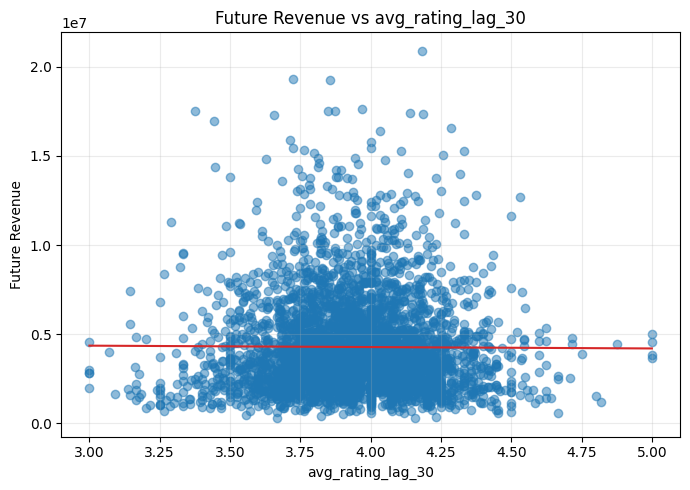

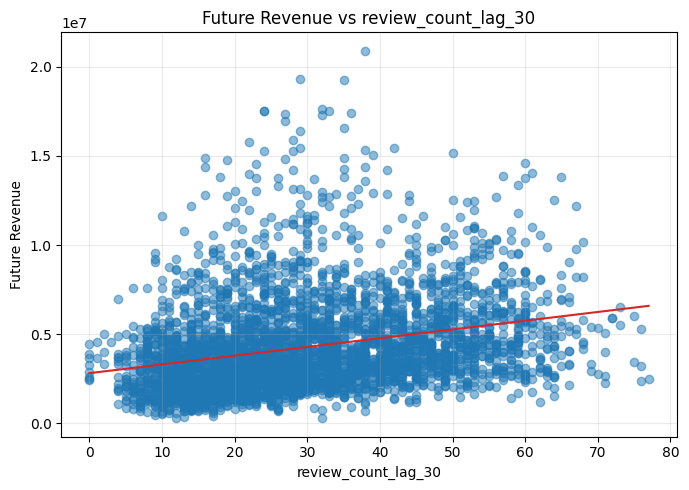

In [11]:
lag_result_rows = []
future_analysis = pd.DataFrame()

if not target.empty:
    target = target.sort_values(date_col).copy()
    is_daily = analysis_freq == 'daily'
    lag7 = 7 if is_daily else 1
    lag30 = 30 if is_daily else 3
    future7 = 7 if is_daily else 1
    future30 = 30 if is_daily else 3
    roll_window = 30 if is_daily else 3

    target['avg_rating_lag_7'] = target['avg_rating'].shift(lag7)
    target['avg_rating_lag_30'] = target['avg_rating'].shift(lag30)
    target['low_rating_ratio_lag_30'] = target['low_rating_ratio'].shift(lag30)
    target['review_count_lag_30'] = target['review_count'].shift(lag30)
    target['future_revenue_7'] = target['revenue'].shift(-future7)
    target['future_revenue_30'] = target['revenue'].shift(-future30)
    target['avg_rating_roll_mean_30'] = target['avg_rating'].shift(1).rolling(roll_window, min_periods=1).mean()
    target['review_count_roll_sum_30'] = target['review_count'].shift(1).rolling(roll_window, min_periods=1).sum()

    pairs = [
        ('avg_rating_lag_7', 'future_revenue_7'),
        ('avg_rating_lag_30', 'future_revenue_30'),
        ('low_rating_ratio_lag_30', 'future_revenue_30'),
        ('review_count_lag_30', 'future_revenue_30'),
        ('avg_rating_roll_mean_30', 'future_revenue_30'),
        ('review_count_roll_sum_30', 'future_revenue_30'),
    ]
    for x, y in pairs:
        lag_result_rows.append({'feature': x, 'target': y, 'correlation': target[x].corr(target[y])})

    future_analysis = pd.DataFrame(lag_result_rows).sort_values('correlation', ascending=False, key=lambda s: s.abs())
    display(future_analysis)

    for feature, title in [('avg_rating_lag_30', 'Future Revenue vs avg_rating_lag_30'),
                           ('review_count_lag_30', 'Future Revenue vs review_count_lag_30')]:
        tmp = target.dropna(subset=[feature, 'future_revenue_30'])
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(tmp[feature], tmp['future_revenue_30'], alpha=0.5)
        if len(tmp) >= 2:
            x = tmp[feature].to_numpy()
            y = tmp['future_revenue_30'].to_numpy()
            if np.nanstd(x) > 0:
                coef = np.polyfit(x, y, 1)
                xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
                ax.plot(xs, coef[0] * xs + coef[1], color='tab:red', linewidth=1.5)
        ax.set_title(title)
        ax.set_xlabel(feature)
        ax.set_ylabel('Future Revenue')
        plt.tight_layout()
        plt.show()

## 12. Product and Category-Level Review and Revenue Analysis

When product-level Revenue can be built, compare review volume and average rating against product and category Revenue.

,product_id_std,product_revenue,product_quantity,order_count,category,segment,product_name,review_count,avg_rating,low_rating_ratio
0,1,"31,302.3200",8,1,Casual,All-weather,DragonWear MA-01,NaN,NaN,NaN
1,3,"26,410,895.5200",2584,581,Casual,All-weather,DragonWear MA-03,99.0000,4.1515,0.0707
2,4,"6,838,217.0300",735,167,Casual,All-weather,DragonWear MA-04,28.0000,3.8571,0.2143
3,5,"7,673.5900",1,1,Casual,All-weather,DragonWear MA-05,NaN,NaN,NaN
4,7,"474,795.8800",95,29,Casual,All-weather,DragonWear MA-07,5.0000,3.8000,0.2000
5,8,"12,013,511.1600",2376,523,Casual,All-weather,DragonWear MA-08,72.0000,4.1250,0.0833
6,9,"10,374,686.6800",1545,343,Casual,All-weather,DragonWear MA-09,63.0000,3.8571,0.1429
7,10,"514,630.5100",65,17,Casual,All-weather,DragonWear MA-10,3.0000,5.0000,0.0000
8,12,"431,470.2500",88,20,Casual,All-weather,DragonWear MA-12,1.0000,5.0000,0.0000
9,13,"1,131,972.1200",228,49,Casual,All-weather,DragonWear MA-13,6.0000,4.3333,0.0000


High-review/high-revenue products


,product_id_std,product_name,category,review_count,avg_rating,product_revenue,product_quantity
543,792,HanoiStreet RP-80,Outdoor,"1,596.0000",3.9073,"33,817,877.4900",45726
542,791,HanoiStreet RP-79,Outdoor,"1,512.0000",3.9530,"33,999,756.2900",45986
410,604,SaigonFlex UC-69,Streetwear,"1,364.0000",3.9978,"207,930,650.9300",36515
1380,2045,UrbanVN UE-05,Streetwear,"1,323.0000",3.9146,"185,081,235.2400",35844
308,487,SaigonFlex UM-92,Streetwear,"1,190.0000",3.9286,"398,213,557.4500",33277
272,438,SaigonFlex UM-43,Streetwear,"1,148.0000",3.8946,"340,706,262.8900",31471
792,1182,MekongFit UE-18,Streetwear,"1,135.0000",4.0238,"65,864,124.0400",31896
601,927,HanoiStreet UE-36,Streetwear,"1,126.0000",3.9556,"168,304,974.1700",31220
1545,2332,VietMotion UE-06,Streetwear,"1,109.0000",3.9486,"177,882,160.8400",32821
566,826,HanoiStreet UM-10,Streetwear,"1,039.0000",3.8239,"342,264,987.7000",28993


High-review/weaker-revenue products


,product_id_std,product_name,category,review_count,avg_rating,product_revenue,product_quantity
718,1093,MekongFit RP-39,Outdoor,111.0000,3.9279,"1,944,581.4200",2949
719,1094,MekongFit RP-40,Outdoor,103.0000,4.0097,"1,877,464.2100",2847
1010,1484,VietMode RP-76,Outdoor,75.0000,3.8933,"1,590,873.4900",1711
1516,2241,VietMotion RP-38,Outdoor,74.0000,3.8784,"2,111,053.8400",2023
1009,1483,VietMode RP-75,Outdoor,73.0000,4.0685,"1,581,476.0700",1696
1515,2240,VietMotion RP-37,Outdoor,62.0000,3.5806,"2,082,640.0000",1995


,category,review_count,avg_rating,revenue,quantity_sold,product_count
3,Streetwear,"62,704.0000",3.9337,"13,131,346,352.6200",1768826,877
2,Outdoor,"41,265.0000",3.9138,"2,494,882,754.2000",1170000,496
0,Casual,"3,790.0000",3.8940,"460,648,383.3500",107469,114
1,GenZ,"5,792.0000",3.9249,"343,599,095.3600",166848,111


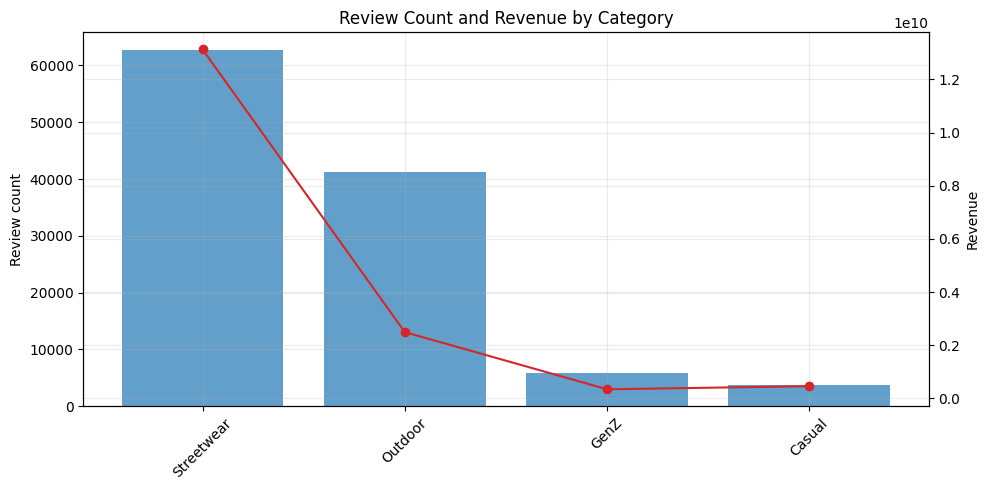

Optional review and return context for products with high review volume, lower ratings, and higher return count


,product_id_std,product_revenue,product_quantity,order_count,category,segment,product_name,review_count,avg_rating,low_rating_ratio,return_count,reviews_and_returns_flag
795,1186,"23,416,340.0700",5492,1181,Streetwear,Performance,MekongFit UE-22,167.0000,3.7485,0.1737,67.0000,True
1582,2389,"32,674,706.4100",3493,787,Streetwear,Everyday,VietMotion UC-37,118.0000,3.6356,0.2203,59.0000,True
1519,2250,"3,809,085.5900",2618,589,Outdoor,Activewear,VietMotion RP-47,98.0000,3.7041,0.1939,35.0000,True
1547,2336,"18,312,203.6300",2283,506,Streetwear,Performance,VietMotion UE-10,81.0000,3.7037,0.2099,34.0000,True
602,930,"14,151,788.7100",2341,522,Streetwear,Performance,HanoiStreet UE-39,77.0000,3.7662,0.2078,34.0000,True
1515,2240,"2,082,640.0000",1995,445,Outdoor,Activewear,VietMotion RP-37,62.0000,3.5806,0.2581,30.0000,True
1288,1884,"26,392,853.6500",2802,629,Streetwear,Everyday,BambooCraft UC-03,110.0000,3.7182,0.1182,29.0000,True
310,489,"22,718,622.5400",2368,525,Streetwear,Balanced,SaigonFlex UM-94,77.0000,3.7532,0.1688,28.0000,True
825,1227,"6,530,158.1800",1848,415,Streetwear,Everyday,MekongFit UC-29,63.0000,3.6667,0.1905,27.0000,True
403,595,"19,039,025.8600",2273,478,Streetwear,Everyday,SaigonFlex UC-60,77.0000,3.7662,0.1429,26.0000,True


In [12]:
product_review_revenue = pd.DataFrame()
category_review_revenue = pd.DataFrame()
return_context = pd.DataFrame()

if reviews_clean is not None and review_cols.get('product_id') and not product_sales.empty:
    review_prod = reviews_clean.copy()
    review_prod['product_id_std'] = review_prod['product_id_std']
    review_prod['low_rating_flag'] = review_prod['rating_std'].le(LOW_RATING_THRESHOLD).fillna(False).astype(int)
    review_prod_summary = review_prod.groupby('product_id_std').agg(
        review_count=('rating_std', 'size'),
        avg_rating=('rating_std', 'mean'),
        low_rating_ratio=('low_rating_flag', 'mean'),
    ).reset_index()
    product_review_revenue = product_sales.merge(review_prod_summary, on='product_id_std', how='outer')
    display(product_review_revenue.head(10))

    enough_reviews = product_review_revenue['review_count'].fillna(0) >= max(5, int(product_review_revenue['review_count'].fillna(0).median() or 5))
    low_revenue_threshold = product_review_revenue['product_revenue'].fillna(0).median()
    high_revenue_threshold = product_review_revenue['product_revenue'].fillna(0).quantile(0.75)
    high_review_threshold = product_review_revenue['review_count'].fillna(0).quantile(0.75)

    high_review_high_revenue = product_review_revenue[
        enough_reviews &
        product_review_revenue['review_count'].fillna(0).ge(high_review_threshold) &
        product_review_revenue['product_revenue'].fillna(0).ge(high_revenue_threshold)
    ].sort_values(['review_count', 'product_revenue'], ascending=False).head(10)

    high_review_low_revenue = product_review_revenue[
        enough_reviews &
        product_review_revenue['review_count'].fillna(0).ge(high_review_threshold) &
        product_review_revenue['product_revenue'].fillna(0).le(low_revenue_threshold)
    ].sort_values(['review_count', 'product_revenue'], ascending=[False, True]).head(10)

    print('High-review/high-revenue products')
    display(high_review_high_revenue[['product_id_std', 'product_name', 'category', 'review_count', 'avg_rating', 'product_revenue', 'product_quantity']])
    print('High-review/weaker-revenue products')
    display(high_review_low_revenue[['product_id_std', 'product_name', 'category', 'review_count', 'avg_rating', 'product_revenue', 'product_quantity']])

    if 'category' in product_review_revenue.columns:
        category_review_revenue = product_review_revenue.groupby('category').agg(
            review_count=('review_count', 'sum'),
            avg_rating=('avg_rating', 'mean'),
            revenue=('product_revenue', 'sum'),
            quantity_sold=('product_quantity', 'sum'),
            product_count=('product_id_std', 'nunique'),
        ).reset_index().sort_values('revenue', ascending=False)
        display(category_review_revenue)

        fig, ax = plt.subplots(figsize=(10, 5))
        ordered = category_review_revenue.sort_values('review_count', ascending=False)
        ax.bar(ordered['category'].astype(str), ordered['review_count'], alpha=0.7, label='Review count')
        ax2 = ax.twinx()
        ax2.plot(ordered['category'].astype(str), ordered['revenue'], color='tab:red', marker='o', label='Revenue')
        ax.set_title('Review Count and Revenue by Category')
        ax.set_ylabel('Review count')
        ax2.set_ylabel('Revenue')
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print('Product-level review and Revenue linkage is unavailable. Time-level analysis above remains valid.')

if returns is not None and return_cols.get('product_id') and not product_review_revenue.empty:
    ret = returns.copy()
    ret['product_id_std'] = ret[return_cols['product_id']]
    ret_counts = ret.groupby('product_id_std').size().reset_index(name='return_count')
    return_context = product_review_revenue.merge(ret_counts, on='product_id_std', how='left')
    return_context['return_count'] = return_context['return_count'].fillna(0)
    return_context['reviews_and_returns_flag'] = (
        return_context['review_count'].fillna(0).ge(return_context['review_count'].fillna(0).quantile(0.75)) &
        return_context['avg_rating'].fillna(return_context['avg_rating'].mean()).le(return_context['avg_rating'].quantile(0.25)) &
        return_context['return_count'].ge(return_context['return_count'].quantile(0.75))
    )
    print('Optional review and return context for products with high review volume, lower ratings, and higher return count')
    display(return_context[return_context['reviews_and_returns_flag']].sort_values('return_count', ascending=False).head(10))

## 13. Leakage-Safe Review and Rating Forecast Feature Preview

Create lagged historical review features only. Future reviews and ratings are not known before prediction and must not be used directly.

In [13]:
feature_preview = pd.DataFrame()

if not target.empty:
    target = target.sort_values(date_col).copy()
    if analysis_freq == 'daily':
        target['review_count_lag_7'] = target['review_count'].shift(7)
        target['review_count_lag_30'] = target['review_count'].shift(30)
        target['avg_rating_lag_7'] = target['avg_rating'].shift(7)
        target['avg_rating_lag_30'] = target['avg_rating'].shift(30)
        target['low_rating_ratio_lag_30'] = target['low_rating_ratio'].shift(30)
        target['review_count_roll_sum_30'] = target['review_count'].shift(1).rolling(30, min_periods=1).sum()
        target['avg_rating_roll_mean_30'] = target['avg_rating'].shift(1).rolling(30, min_periods=1).mean()
        target['low_rating_ratio_roll_mean_30'] = target['low_rating_ratio'].shift(1).rolling(30, min_periods=1).mean()
    else:
        target['review_count_lag_7'] = target['review_count'].shift(1)
        target['review_count_lag_30'] = target['review_count'].shift(3)
        target['avg_rating_lag_7'] = target['avg_rating'].shift(1)
        target['avg_rating_lag_30'] = target['avg_rating'].shift(3)
        target['low_rating_ratio_lag_30'] = target['low_rating_ratio'].shift(3)
        target['review_count_roll_sum_30'] = target['review_count'].shift(1).rolling(3, min_periods=1).sum()
        target['avg_rating_roll_mean_30'] = target['avg_rating'].shift(1).rolling(3, min_periods=1).mean()
        target['low_rating_ratio_roll_mean_30'] = target['low_rating_ratio'].shift(1).rolling(3, min_periods=1).mean()

    if not category_review_revenue.empty and 'category' in category_review_revenue.columns:
        category_pressure = category_review_revenue[['category', 'avg_rating']].copy()
        category_pressure['category_low_rating_pressure_lag'] = 5 - category_pressure['avg_rating']
        category_pressure_value = category_pressure['category_low_rating_pressure_lag'].mean()
    else:
        category_pressure_value = np.nan

    target['category_low_rating_pressure_lag'] = category_pressure_value
    preview_cols = [
        date_col, 'revenue', 'review_count', 'avg_rating', 'low_rating_ratio', 'high_rating_ratio',
        'review_count_lag_7', 'review_count_lag_30', 'avg_rating_lag_7', 'avg_rating_lag_30',
        'low_rating_ratio_lag_30', 'review_count_roll_sum_30', 'avg_rating_roll_mean_30',
        'low_rating_ratio_roll_mean_30', 'category_low_rating_pressure_lag'
    ]
    feature_preview = target[preview_cols].head(20)
    display(feature_preview)

print('Historical-only features shown above are leakage-safe if computed strictly from reviews posted before the forecast date.')
print('Do not use future review count or future rating directly unless those values are genuinely known before prediction.')

,date,revenue,review_count,avg_rating,low_rating_ratio,high_rating_ratio,review_count_lag_7,review_count_lag_30,avg_rating_lag_7,avg_rating_lag_30,low_rating_ratio_lag_30,review_count_roll_sum_30,avg_rating_roll_mean_30,low_rating_ratio_roll_mean_30,category_low_rating_pressure_lag
0,2012-07-04,"5,123,547.9400",0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0834
1,2012-07-05,"2,751,773.4500",0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,1.0834
2,2012-07-06,"3,054,029.4200",0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,1.0834
3,2012-07-07,"2,667,930.9400",0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,1.0834
4,2012-07-08,"2,360,851.9000",0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,1.0834
5,2012-07-09,"3,548,386.4600",0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,1.0834
6,2012-07-10,"5,234,938.6200",1.0000,5.0000,0.0000,1.0000,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,1.0834
7,2012-07-11,"5,582,884.7800",0.0000,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,1.0000,5.0000,0.0000,1.0834
8,2012-07-12,"5,734,632.0200",1.0000,5.0000,0.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,1.0000,5.0000,0.0000,1.0834
9,2012-07-13,"5,309,511.7100",2.0000,4.5000,0.0000,1.0000,0.0000,NaN,NaN,NaN,NaN,2.0000,5.0000,0.0000,1.0834


Historical-only features shown above are leakage-safe if computed strictly from reviews posted before the forecast date.
Do not use future review count or future rating directly unless those values are genuinely known before prediction.


## 14. Key Observations and Warnings

Summarize the descriptive findings, data-quality warnings, and recommended historical review features.

In [14]:
summary_lines = ['KEY OBSERVATIONS AND WARNINGS']

if reviews_clean is not None and reviews_clean['rating_std'].notna().any():
    avg_rating = reviews_clean['rating_std'].mean()
    low_ratio = reviews_clean['rating_std'].le(LOW_RATING_THRESHOLD).mean()
    first_30 = daily_reviews['review_count'].head(30).mean() if not daily_reviews.empty and len(daily_reviews) >= 30 else np.nan
    last_30 = daily_reviews['review_count'].tail(30).mean() if not daily_reviews.empty and len(daily_reviews) >= 30 else np.nan
    if pd.notna(first_30) and pd.notna(last_30):
        if last_30 > first_30 * 1.05:
            review_trend = 'increasing'
        elif last_30 < first_30 * 0.95:
            review_trend = 'decreasing'
        else:
            review_trend = 'stable'
    else:
        review_trend = 'unclear'
    summary_lines.append(f'- Review count over time appears {review_trend}.')
    summary_lines.append(f'- Overall average rating: {avg_rating:.4f}.')
    summary_lines.append(f'- Low-rating ratio (<= {LOW_RATING_THRESHOLD}): {low_ratio:.2%}.')

if correlation_rows:
    corr_df = pd.DataFrame(correlation_rows)
    same = corr_df.loc[corr_df['metric'] == 'revenue_vs_same_period_review_count', 'correlation']
    lagged = corr_df.loc[corr_df['metric'] == 'revenue_vs_lagged_review_count_long', 'correlation']
    if not same.empty:
        summary_lines.append(f'- Same-period review count vs Revenue correlation: {same.iloc[0]:.4f}.')
    if not lagged.empty:
        summary_lines.append(f'- Lagged review count vs Revenue correlation: {lagged.iloc[0]:.4f}.')

if 'proxy_corr' in locals():
    summary_lines.append(
        f"- Review count as sales-volume proxy: order_count corr={proxy_corr.loc[0, 'review_vs_order_count']:.4f}, "
        f"quantity_sold corr={proxy_corr.loc[0, 'review_vs_quantity_sold']:.4f}, Revenue corr={proxy_corr.loc[0, 'review_vs_item_revenue']:.4f}."
    )

if not future_analysis.empty:
    best_future = future_analysis.iloc[0]
    summary_lines.append(f"- Strongest displayed historical review feature vs future Revenue: {best_future['feature']} ({best_future['correlation']:.4f}).")

if not category_review_revenue.empty:
    top_cat = category_review_revenue.sort_values('review_count', ascending=False).head(3)
    bottom_rev = category_review_revenue.sort_values('revenue', ascending=True).head(3)
    summary_lines.append('- Categories with high review volume and high Revenue: ' + ', '.join(f"{r.category}" for r in top_cat.itertuples()) + '.')
    summary_lines.append('- Categories with weaker Revenue in the category summary tail: ' + ', '.join(f"{r.category}" for r in bottom_rev.itertuples()) + '.')

if review_warnings or sales_warnings:
    summary_lines.append('- Data quality warnings: ' + '; '.join(review_warnings + sales_warnings))
else:
    summary_lines.append('- Data quality warnings: none beyond the checks reported in notebook tables.')

summary_lines.append('- Recommended leakage-safe review/rating forecast features: review_count_lag_7, review_count_lag_30, avg_rating_lag_7, avg_rating_lag_30, low_rating_ratio_lag_30, review_count_roll_sum_30, avg_rating_roll_mean_30, and low_rating_ratio_roll_mean_30.')
summary_lines.append('- Future reviews and ratings must not be used directly for forecasting unless they are genuinely known before prediction.')
summary_lines.append('- Causal caution: this is observational EDA. High sales can create more reviews, and rating shifts can reflect product mix, expectations, promotion mix, seasonality, or customer composition.')

print('\n'.join(summary_lines))

KEY OBSERVATIONS AND WARNINGS
- Review count over time appears decreasing.
- Overall average rating: 3.9360.
- Low-rating ratio (<= 2): 13.09%.
- Same-period review count vs Revenue correlation: 0.5598.
- Lagged review count vs Revenue correlation: 0.4331.
- Review count as sales-volume proxy: order_count corr=0.5876, quantity_sold corr=0.5751, Revenue corr=0.5611.
- Strongest displayed historical review feature vs future Revenue: review_count_roll_sum_30 (0.3845).
- Categories with high review volume and high Revenue: Streetwear, Outdoor, GenZ.
- Categories with weaker Revenue in the category summary tail: GenZ, Casual, Outdoor.
- Data quality warnings: none beyond the checks reported in notebook tables.
- Recommended leakage-safe review/rating forecast features: review_count_lag_7, review_count_lag_30, avg_rating_lag_7, avg_rating_lag_30, low_rating_ratio_lag_30, review_count_roll_sum_30, avg_rating_roll_mean_30, and low_rating_ratio_roll_mean_30.
- Future reviews and ratings must no